In [1]:
from qiskit import __version__
print(__version__)

2.1.1


In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, CXGate, RYGate
import matplotlib.pyplot as plt

In [3]:
theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))
amp_0 = np.cos(theta/2)
amp_1 = np.sin(theta/2)

In [4]:
H_matrix = HGate().to_matrix()
hadamard_custom = UnitaryGate(H_matrix, label='hadamard_custom')

CX_matrix = CXGate().to_matrix()
cx_custom = UnitaryGate(CX_matrix, label='cx_custom')

RY_matrix = RYGate(theta).to_matrix()
ry_custom = UnitaryGate(RY_matrix, label='ry_custom')

# Infidelity to error rates

In [5]:
def inf_to_error(infidelity_list, num_qubits):
    error_rates_list = []
    dimension = 2**num_qubits
    for infidelity in infidelity_list:
        error_rates_list.append( infidelity * (dimension / (dimension - 1)) )
    
    return error_rates_list

In [6]:
one_qubit_gate_infidelity = [2.8e-5 * i for i in range(1,6)]
two_qubit_gate_infidelity = [8.3e-4 * i for i in range(1,6)]
idle_gate_infidelity = [1.2e-4 * i for i in range(1,6)]
spam0 = [6.7e-4 * i for i in range(1,6)] # P(1|0), measured 1 given that 0 was prepared
spam1 = [1.2e-3 * i for i in range(1,6)] # P(0|1)

In [7]:
one_qubit_gate_error_prob = inf_to_error(one_qubit_gate_infidelity, num_qubits=1)
two_qubit_gate_error_prob = inf_to_error(two_qubit_gate_infidelity, num_qubits=2)
idle_gate_error_prob = inf_to_error(idle_gate_infidelity, num_qubits=1)

# Functions

Qubits are ordered from top to down, left to right, increasingly

The logical operators act on the left side of the triangle

In [8]:
def ideal_encoding(qc: QuantumCircuit, start: int):
    for i in [2,3,5]:
        qc.append(hadamard_custom, [start+i])
        
    cx_list = [[0,4], [0,1], [2,6], [2,4], [2,0], [5,6], [5,1], [5,0], [3,6], [3,1], [3,4]]
    for cx in cx_list:
        cx[0] += start
        cx[1] += start
        qc.append(cx_custom, cx)

In [9]:
def encoding(qc: QuantumCircuit, start: int):
    for i in [2,3,5]:
        qc.h(start+i)
    
    cx_list = [[0,4], [0,1], [2,6], [2,4], [2,0], [5,6], [5,1], [5,0], [3,6], [3,1], [3,4]]
    for cx in cx_list:
        cx[0] += start 
        cx[1] += start 
        qc.cx(cx[0], cx[1])

In [10]:
def ideal_syndrome_meas(qc, start, x_ancillas, z_ancillas, x_syndrome, z_syndrome):
    qc.h(x_ancillas)
    
    for i in [0,1,2,3]:
        qc.append(cx_custom, [start+i, z_ancillas[0]])
        qc.append(cx_custom, [x_ancillas[0], start+i])
    for i in [1,2,4,5]:
        qc.append(cx_custom, [start+i, z_ancillas[1]])
        qc.append(cx_custom, [x_ancillas[1], start+i])
    for i in [2,3,5,6]:
        qc.append(cx_custom, [start+i, z_ancillas[2]])
        qc.append(cx_custom, [x_ancillas[2], start+i])
        
    qc.h(x_ancillas)
    
    qc.measure(x_ancillas, x_syndrome)
    qc.measure(z_ancillas, z_syndrome)

In [11]:
def ideal_logical_rz(qc: QuantumCircuit, start: int):
    qc.append(cx_custom, [start+6, start+5])
    qc.append(rzz_custom, [start+4, start+5])
    qc.append(cx_custom, [start+6, start+5])

In [12]:
def logical_rz(qc: QuantumCircuit, start: int, theta: float):
    qc.cx(start+6, start+5)
    qc.rzz(theta, start+4, start+5)
    qc.cx(start+6, start+5)

# Testing syndrome measurements

In [30]:
test = QuantumCircuit(7)

x_ancillas = QuantumRegister(3)
z_ancillas = QuantumRegister(3)
x_syndrome = ClassicalRegister(3)
z_syndrome = ClassicalRegister(3)

test.add_register(x_ancillas, z_ancillas, x_syndrome, z_syndrome)

#test.x(5)
ideal_encoding(test, 0)
ideal_syndrome_meas(test, 0, x_ancillas, z_ancillas, x_syndrome, z_syndrome)

noise_model = NoiseModel()
meas_circuit_noise = test.copy()
meas_circuit_noise.save_statevector(label='state_post', pershot=True, conditional=True)

backend = AerSimulator(noise_model=noise_model)
transpiled = transpile(meas_circuit_noise, backend, optimization_level=0)
job = backend.run(transpiled, shots=1)
result = job.result()
res_statevectors = result.data()['state_post']
print(res_statevectors)

{'0x0': [Statevector([0.35355339-3.1918912e-15j, 0.        +0.0000000e+00j,
             0.        +0.0000000e+00j, ..., 0.        +0.0000000e+00j,
             0.        +0.0000000e+00j, 0.        +0.0000000e+00j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2))]}


In [157]:
test1 = QuantumCircuit(21,14)
ideal_encoding(test1, 0)
ideal_encoding(test1, 7)
ideal_encoding(test1, 14)

for i in range(21):
    test1.s(i)
    test1.h(i)
ideal_logical_rz(test1, 0, theta)
ideal_logical_rz(test1, 7, theta)
ideal_logical_rz(test1, 14, theta)
for i in range(21):
    test1.h(i)
    test1.sdg(i)
    
x_ancillas1 = QuantumRegister(3)
z_ancillas1 = QuantumRegister(3)
x_syndrome1 = ClassicalRegister(3)
z_syndrome1 = ClassicalRegister(3)

test1.add_register(x_ancillas1, z_ancillas1, x_syndrome1, z_syndrome1)
    
ideal_syndrome_meas(test1, 14, x_ancillas1, z_ancillas1, x_syndrome1, z_syndrome1)

In [158]:
noise_model = NoiseModel()
meas_circuit_noise = test1.copy()

backend = AerSimulator(noise_model=noise_model)
transpiled = transpile(meas_circuit_noise, backend, optimization_level=0)
job = backend.run(transpiled, shots=1)
result = job.result()
counts = result.get_counts()
print(counts)

{'000 000 00000000000000': 1}


# Finding percentage of measuring all fourteen 0s

In [13]:
circuit = QuantumCircuit(21,14)
for i in [0,7,14]:
    circuit.append(ry_custom, [i])
ideal_encoding(circuit, 0)
ideal_encoding(circuit, 7)
ideal_encoding(circuit, 14)
 
for i in range(7):
    circuit.cz(i, i+7)
    circuit.h(i+14)

for i in range(7):
    circuit.cz(i+7, i+14)
    
for i in range(14):
    circuit.h(i)

In [51]:
shots = 1_000

noise_model = NoiseModel()
meas_circuit_noise = circuit.copy()
meas_circuit_noise.measure([i for i in range(14)], [i for i in range(14)]) 

backend = AerSimulator(noise_model=noise_model)
transpiled = transpile(meas_circuit_noise, backend, optimization_level=0)
job = backend.run(transpiled, shots=shots)
result = job.result()

counts = result.get_counts()

correct = 0
for key, values in counts.items():
    block1_syndrome = str(key)[0:7]
    block2_syndrome = str(key)[7:14]
    
    block1_parity1 = (int(block1_syndrome[-1]) + int(block1_syndrome[-2]) + int(block1_syndrome[-3]) + int(block1_syndrome[-4])) % 2
    block1_parity2 = (int(block1_syndrome[-2]) + int(block1_syndrome[-3]) + int(block1_syndrome[-5]) + int(block1_syndrome[-6])) % 2
    block1_parity3 = (int(block1_syndrome[-3]) + int(block1_syndrome[-4]) + int(block1_syndrome[-6]) + int(block1_syndrome[-7])) % 2
    block1_logical_op = (int(block1_syndrome[-1]) + int(block1_syndrome[-2]) + int(block1_syndrome[-5])) % 2 
    
    block2_parity1 = (int(block2_syndrome[-1]) + int(block2_syndrome[-2]) + int(block2_syndrome[-3]) + int(block2_syndrome[-4])) % 2
    block2_parity2 = (int(block2_syndrome[-2]) + int(block2_syndrome[-3]) + int(block2_syndrome[-5]) + int(block2_syndrome[-6])) % 2
    block2_parity3 = (int(block2_syndrome[-3]) + int(block2_syndrome[-4]) + int(block2_syndrome[-6]) + int(block2_syndrome[-7])) % 2
    block2_logical_op = (int(block2_syndrome[-1]) + int(block2_syndrome[-2]) + int(block2_syndrome[-5])) % 2
    
    parity_list = [block1_parity1, block1_parity2, block1_parity3, block1_logical_op, block2_parity1, block2_parity2, block2_parity3, block2_logical_op]
    if (parity_list == [0,0,0,0,0,0,0,0]):
        correct += values

print(f"Probability of measuring correct outputs: {correct/shots * 100}%")

Probability of measuring correct outputs: 41.4%


# Fidelity Simulations

In [13]:
ideal = QuantumCircuit(7)
ideal.append(ry_custom, [0])
ideal_encoding(ideal, 0)
    
ideal = Statevector(ideal)

In [14]:
circuit = QuantumCircuit(21,14)
for i in [0,7,14]:
    circuit.ry(theta, i)
encoding(circuit, 0)
encoding(circuit, 7)
encoding(circuit, 14)
    
for i in range(7):
    circuit.cz(i, i+7)
    circuit.h(i+14)

for i in range(7):
    circuit.cz(i+7, i+14)
    
for i in range(14):
    circuit.h(i)

In [86]:
noise_model = NoiseModel()
meas_circuit_noise = circuit.copy()
meas_circuit_noise.measure([i for i in range(14)], [i for i in range(14)]) 
meas_circuit_noise.save_statevector(label='state_post', pershot=True, conditional=True)

backend = AerSimulator(noise_model=noise_model)
transpiled = transpile(meas_circuit_noise, backend, optimization_level=0)
job = backend.run(transpiled, shots=100)
result = job.result()
counts = result.get_counts()
res_statevectors = result.data()['state_post']

sumfid = 0
correct = 0
for key, sv_list in res_statevectors.items():
    binary_string = format(int(key, 16), 'b').zfill(14)
    
    block1_syndrome = str(binary_string)[0:7]
    block2_syndrome = str(binary_string)[7:14]
    
    block1_parity1 = (int(block1_syndrome[-1]) + int(block1_syndrome[-2]) + int(block1_syndrome[-3]) + int(block1_syndrome[-4])) % 2
    block1_parity2 = (int(block1_syndrome[-2]) + int(block1_syndrome[-3]) + int(block1_syndrome[-5]) + int(block1_syndrome[-6])) % 2
    block1_parity3 = (int(block1_syndrome[-3]) + int(block1_syndrome[-4]) + int(block1_syndrome[-6]) + int(block1_syndrome[-7])) % 2
    block1_logical_op = (int(block1_syndrome[-1]) + int(block1_syndrome[-2]) + int(block1_syndrome[-5])) % 2 
    
    block2_parity1 = (int(block2_syndrome[-1]) + int(block2_syndrome[-2]) + int(block2_syndrome[-3]) + int(block2_syndrome[-4])) % 2
    block2_parity2 = (int(block2_syndrome[-2]) + int(block2_syndrome[-3]) + int(block2_syndrome[-5]) + int(block2_syndrome[-6])) % 2
    block2_parity3 = (int(block2_syndrome[-3]) + int(block2_syndrome[-4]) + int(block2_syndrome[-6]) + int(block2_syndrome[-7])) % 2
    block2_logical_op = (int(block2_syndrome[-1]) + int(block2_syndrome[-2]) + int(block2_syndrome[-5])) % 2
    
    parity_list = [block1_parity1, block1_parity2, block1_parity3, block1_logical_op, block2_parity1, block2_parity2, block2_parity3, block2_logical_op]
    if (parity_list == [0,0,0,0,0,0,0,0]):
        correct += len(sv_list)
        for sv in sv_list:
            red_sv = partial_trace(sv, [i for i in range(14)])
            sumfid += state_fidelity(ideal, red_sv)

In [87]:
print(correct)
print(sumfid/correct)

41
0.9999999999999998


In [15]:
# All errors added
# 1,000 shots took 40min
all_fidelity = []
all_fidelity_unc = []
shots = 3_000

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['h'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    #noise_model.add_all_qubit_quantum_error(depolarizing_error(idle_gate_error_prob[i], 1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cz'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cx']) 
    
    readout_err = ReadoutError([[1-spam0[i], spam0[i]],  # P(0|0), P(1|0)
                            [spam1[i], 1-spam1[i]]]) # P(0|1), P(1|1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([i for i in range(14)], [i for i in range(14)]) 
    meas_circuit_noise.save_statevector(label='state_post', pershot=True, conditional=True)

    backend = AerSimulator(noise_model=noise_model, method='statevector')
    transpiled = transpile(meas_circuit_noise, backend, optimization_level=0)
    job = backend.run(transpiled, shots=shots)
    result = job.result()
    
    res_statevectors = result.data()['state_post']
    sumfid = 0
    correct = 0
    for key, sv_list in res_statevectors.items():
        binary_string = format(int(key, 16), 'b').zfill(14)
        
        block1_syndrome = str(binary_string)[0:7]
        block2_syndrome = str(binary_string)[7:14]
        
        block1_parity1 = (int(block1_syndrome[-1]) + int(block1_syndrome[-2]) + int(block1_syndrome[-3]) + int(block1_syndrome[-4])) % 2
        block1_parity2 = (int(block1_syndrome[-2]) + int(block1_syndrome[-3]) + int(block1_syndrome[-5]) + int(block1_syndrome[-6])) % 2
        block1_parity3 = (int(block1_syndrome[-3]) + int(block1_syndrome[-4]) + int(block1_syndrome[-6]) + int(block1_syndrome[-7])) % 2
        block1_logical_op = (int(block1_syndrome[-1]) + int(block1_syndrome[-2]) + int(block1_syndrome[-5])) % 2 
        
        block2_parity1 = (int(block2_syndrome[-1]) + int(block2_syndrome[-2]) + int(block2_syndrome[-3]) + int(block2_syndrome[-4])) % 2
        block2_parity2 = (int(block2_syndrome[-2]) + int(block2_syndrome[-3]) + int(block2_syndrome[-5]) + int(block2_syndrome[-6])) % 2
        block2_parity3 = (int(block2_syndrome[-3]) + int(block2_syndrome[-4]) + int(block2_syndrome[-6]) + int(block2_syndrome[-7])) % 2
        block2_logical_op = (int(block2_syndrome[-1]) + int(block2_syndrome[-2]) + int(block2_syndrome[-5])) % 2
        
        parity_list = [block1_parity1, block1_parity2, block1_parity3, block1_logical_op, block2_parity1, block2_parity2, block2_parity3, block2_logical_op]
        if (parity_list == [0,0,0,0,0,0,0,0]):
            correct += len(sv_list)
            for sv in sv_list:
                red_sv = partial_trace(sv, [i for i in range(14)])
                sumfid += state_fidelity(ideal, red_sv)
    sumfid /= correct
    
    all_fidelity.append(sumfid)
    all_fidelity_unc.append( 1.96 * np.sqrt( (sumfid)*(1 - sumfid) / correct) )

all_infidelity = [1-f for f in all_fidelity]

In [16]:
print(all_fidelity)

[0.9898087879978613, 0.9857980595734345, 0.9821037498955535, 0.9774582696852787, 0.95976389124621]


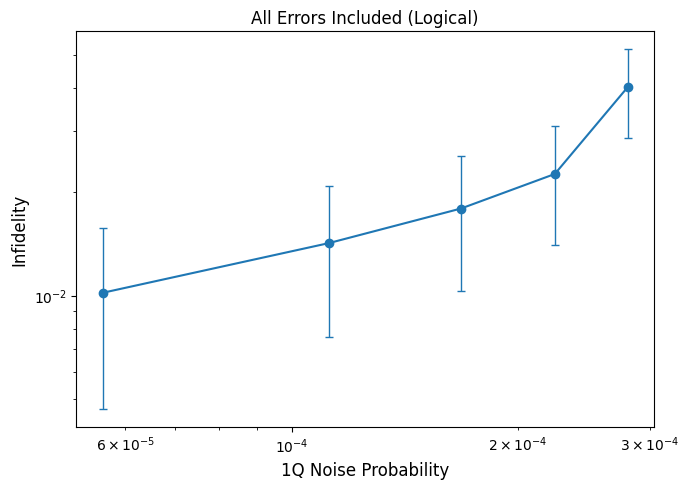

In [18]:
plt.figure(figsize=(7, 5))
plt.errorbar(
    one_qubit_gate_error_prob,
    all_infidelity,
    yerr=all_fidelity_unc,
    fmt='o-',           # circle marker and solid line
    capsize=3,          # length of the little “T” caps on each bar
    elinewidth=1,       # width of the error‐bar lines
    markeredgewidth=1
)
plt.xlabel("1Q Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.title("All Errors Included (Logical)")
plt.tight_layout()
plt.show()